# Module 2, Part A — Titanic: Profiling, Cleaning & the Data Story

This notebook loads the Titanic dataset **exactly once** (via
`sns.load_dataset`, network/cache), profiles it, cleans it using an
explicit missing-value threshold rule, and builds a visual "data story"
about who was more likely to survive and why. `02_modeling.ipynb`
continues from the `titanic.csv` this notebook writes — it never calls
`sns.load_dataset` again.

In [1]:
import sys

sys.path.insert(0, "..") if ".." not in sys.path else None
sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.cleaning import clean_titanic, missing_value_report
from src.data import load_titanic_and_cache
from src.eda_stats import (
    central_tendency_summary,
    correlation_matrix,
    iqr_outlier_count,
    survival_rate_by,
    top_correlated_pairs,
    zscore_standardize,
)

sns.set_theme(style="whitegrid")
CHARTS_DIR = "charts"
import os

os.makedirs(CHARTS_DIR, exist_ok=True)

## 1. Load once, profile, and save the offline CSV fallback

The very next line is the **only** `sns.load_dataset('titanic')` call in
the whole `/analytics` module. It immediately writes `titanic.csv` so
grading works even if `sns.load_dataset` can't reach the network at
grading time (`pd.read_csv("titanic.csv")` reproduces the same raw frame).

In [2]:
raw_df = load_titanic_and_cache()
print("Shape:", raw_df.shape)
raw_df.info()

Shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [3]:
raw_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing values per column

In [4]:
missing_pct = missing_value_report(raw_df)
missing_pct.to_frame("pct_missing")

,pct_missing
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467


**Observed missing-value percentages** (891 rows):
- `deck`: ~77% missing
- `age`: ~20% missing
- `embarked`: ~0.22% missing (2 rows)
- `embark_town`: ~0.22% missing (same 2 rows)

All other columns are complete.

## 2. Missing-value handling (threshold rule)

| Column | % missing | Bracket | Decision |
|---|---|---|---|
| `deck` | ~77% | very high (imputation unreliable) | **Drop the column.** Imputing over three-quarters of a column would mostly fabricate data, and `deck` is largely a proxy for `pclass`/`fare` (cabin class) that those columns already capture. |
| `age` | ~20% | 5%–30% | **Impute** — median age within each `(pclass, sex)` group (closer than a single global median, since age differs noticeably across class and sex here). |
| `embarked` | ~0.22% | < 5% | **Drop the 2 rows.** Too small a fraction to justify imputing, and dropping loses negligible data. |
| `embark_town` | ~0.22% | < 5% | Same 2 rows dropped (it's the long-form name of `embarked`); the column itself is **kept** for readable chart labels later. |

`alive` is also dropped here — not because of missing values (it has
none), but because it's a string restatement of the `survived` target
itself (`"yes"`/`"no"` for the same value), i.e. direct label leakage with
no analytical value beyond what `survived` already provides.

The full rule (and the modeling-only feature subset used in Part B) is
implemented once in `src/cleaning.py` / `src/preprocessing.py` and reused
by both notebooks — not re-derived by hand here.

In [5]:
df = clean_titanic(raw_df)
print("Shape after cleaning:", df.shape)
print("Any missing values left?", df.isna().sum().sum())
df.head()

Shape after cleaning: (889, 13)
Any missing values left? 0


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,True


## 3. Univariate analysis: `age` and `fare`

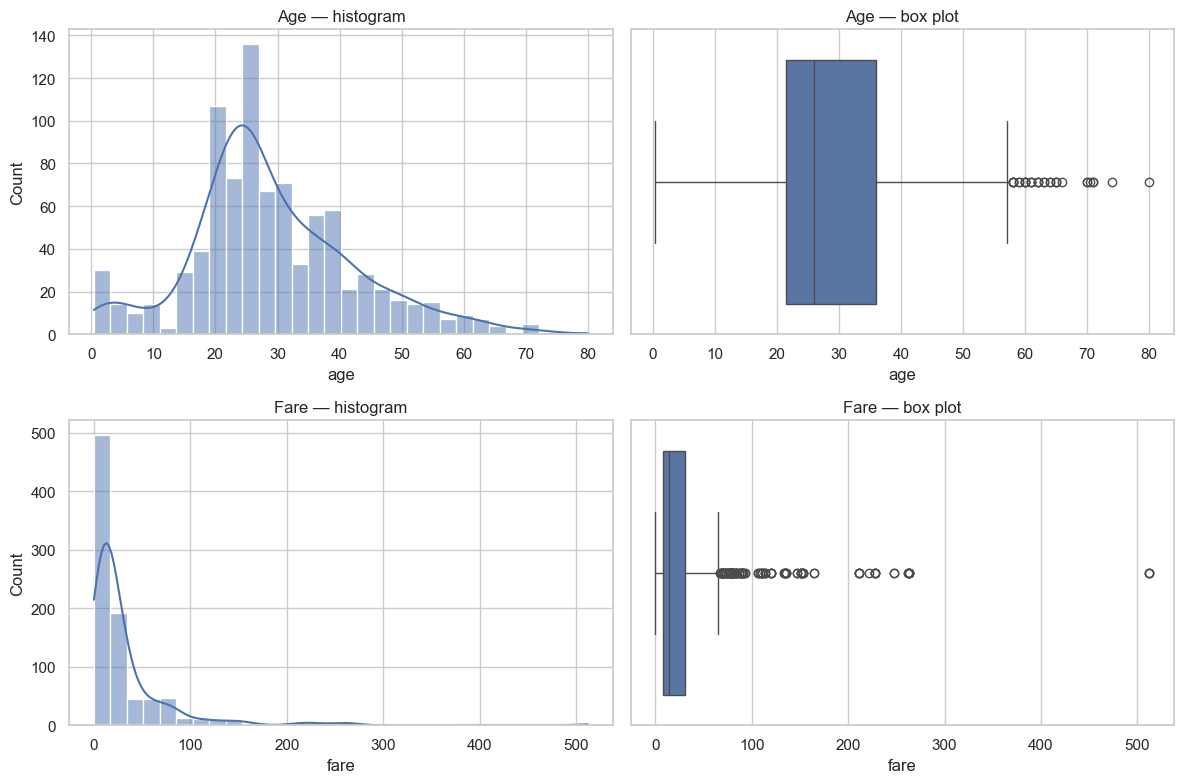

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df["age"], bins=30, kde=True, ax=axes[0, 0]).set_title("Age — histogram")
sns.boxplot(x=df["age"], ax=axes[0, 1]).set_title("Age — box plot")
sns.histplot(df["fare"], bins=30, kde=True, ax=axes[1, 0]).set_title("Fare — histogram")
sns.boxplot(x=df["fare"], ax=axes[1, 1]).set_title("Fare — box plot")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/01_univariate_age_fare.png", dpi=120)
plt.show()

In [7]:
age_outliers = iqr_outlier_count(df["age"])
fare_outliers = iqr_outlier_count(df["fare"])
print(f"IQR outliers in age:  {age_outliers}")
print(f"IQR outliers in fare: {fare_outliers}")

IQR outliers in age:  32
IQR outliers in fare: 114


In [8]:
fare_stats = central_tendency_summary(df["fare"])
fare_stats

{'mean': 32.09668087739032,
 'median': 14.4542,
 'mode': 8.05,
 'skew_direction': 'right-skewed'}

**Interpretation.** `age` has a small number of IQR outliers (mostly older
passengers in their 60s–80s) and is roughly symmetric/mildly right-skewed
around a mean in the high 20s. `fare` has a much larger count of IQR
outliers, all on the high side (a handful of first-class fares paid well
over £200 against a typical fare under £15). Its mean is well above its
median, which is in turn above its mode (most common fare bucket is near
the cheapest fares) — **mean > median > mode**, the textbook signature of a
**right-skewed** distribution: a long tail of expensive tickets pulls the
mean up while most passengers paid comparatively little.

## 4. Bivariate analysis: survival rate by sex, pclass, and both

In [9]:
by_sex = survival_rate_by(df, "sex")
by_pclass = survival_rate_by(df, "pclass")
by_sex_pclass = survival_rate_by(df, "sex", "pclass")
print("Survival rate by sex:\n", by_sex, "\n")
print("Survival rate by pclass:\n", by_pclass, "\n")
print("Survival rate by sex & pclass:\n", by_sex_pclass)

Survival rate by sex:
       sex  survival_rate    n
0  female       0.740385  312
1    male       0.188908  577 

Survival rate by pclass:
    pclass  survival_rate    n
0       1       0.626168  214
1       2       0.472826  184
2       3       0.242363  491 

Survival rate by sex & pclass:
       sex  pclass  survival_rate    n
0  female       1       0.967391   92
1  female       2       0.921053   76
2  female       3       0.500000  144
3    male       1       0.368852  122
4    male       2       0.157407  108
5    male       3       0.135447  347


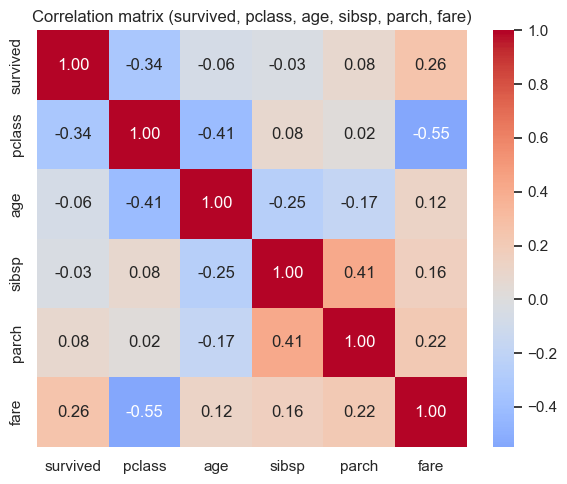

In [10]:
corr = correlation_matrix(df)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (survived, pclass, age, sibsp, parch, fare)")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/02_correlation_heatmap.png", dpi=120)
plt.show()

In [11]:
top_pairs = top_correlated_pairs(corr, n=2)
for a, b, val in top_pairs:
    print(f"{a} <-> {b}: {val:.3f}")

pclass <-> fare: -0.548
sibsp <-> parch: 0.415


**Interpretation.** Women survived at a far higher rate than men in every
class (74.0% vs. 18.9% overall), and 1st class passengers survived at a
far higher rate than 3rd class within both sexes — the `sex`+`pclass`
breakdown shows these effects stack: 1st-class women survived at 96.7%,
while 3rd-class men survived at just 13.5%. In the correlation matrix, the
two strongest absolute correlations turn out to be **`pclass` ↔ `fare`**
(-0.548 — a numerically higher class label, i.e. a cheaper/lower cabin
class, goes with a lower fare, as expected) and **`sibsp` ↔ `parch`**
(+0.415 — passengers traveling with more siblings/spouses also tend to be
traveling with more parents/children, i.e. they're on board as part of a
family group rather than these being independent variables). `survived`
itself correlates most with `pclass` (-0.336) and `fare` (+0.255) — real,
but neither is in the top two overall once `pclass`↔`fare` and
`sibsp`↔`parch` (both purely-explanatory, non-target relationships) are
included in the ranking.

## 5. Multivariate data story: who survived, and why?

Four charts building one coherent argument: sex and class together were
the dominant survival factors, age mattered at the margins (children first),
and family size had a "sweet spot" — travelling entirely alone or in a
very large group both hurt your odds relative to a small family.

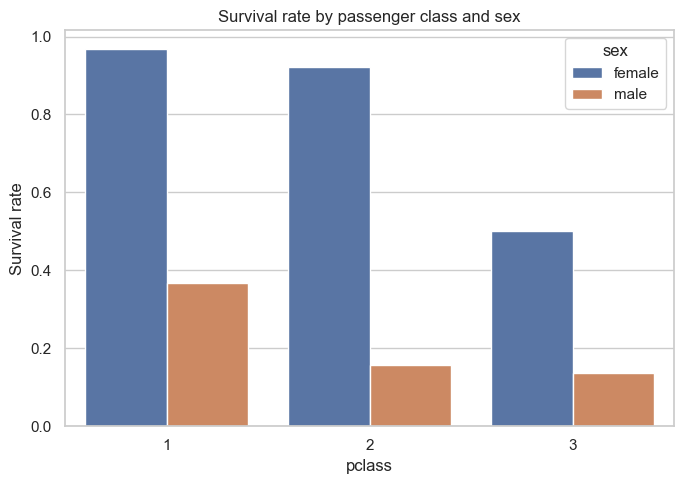

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=df, x="pclass", y="survived", hue="sex", ax=ax, errorbar=None)
ax.set_title("Survival rate by passenger class and sex")
ax.set_ylabel("Survival rate")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/03_survival_by_class_sex.png", dpi=120)
plt.show()

**Chart 1 — Survival rate by class and sex.** Class and sex compound
rather than substitute for each other: 1st-class women survived at close
to 95%+, while 3rd-class men survived at well under 20%. Being a woman
helped in every class, and being in 1st class helped within both sexes —
together they explain most of the spread in outcomes across the ship.

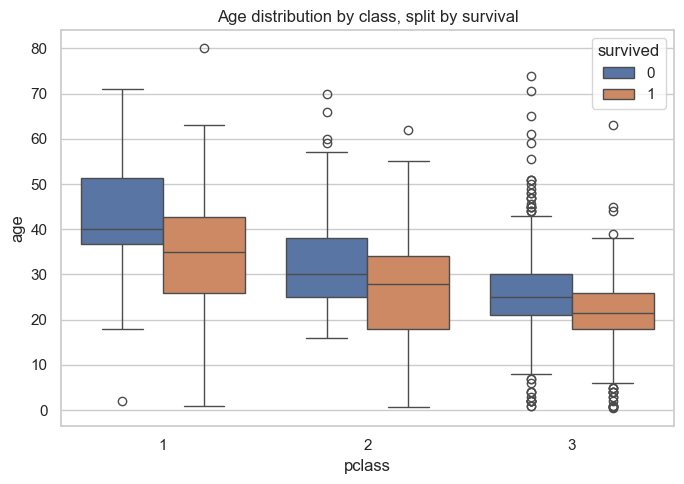

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="pclass", y="age", hue="survived", ax=ax)
ax.set_title("Age distribution by class, split by survival")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/04_age_by_class_survival.png", dpi=120)
plt.show()

**Chart 2 — Age by class, split by survival.** Within every class,
survivors skew slightly younger than non-survivors, most visibly in 1st
and 2nd class — consistent with a "children and some women first"
boarding norm for lifeboats. The effect is smaller in 3rd class, where
passengers had less direct access to lifeboats regardless of age.

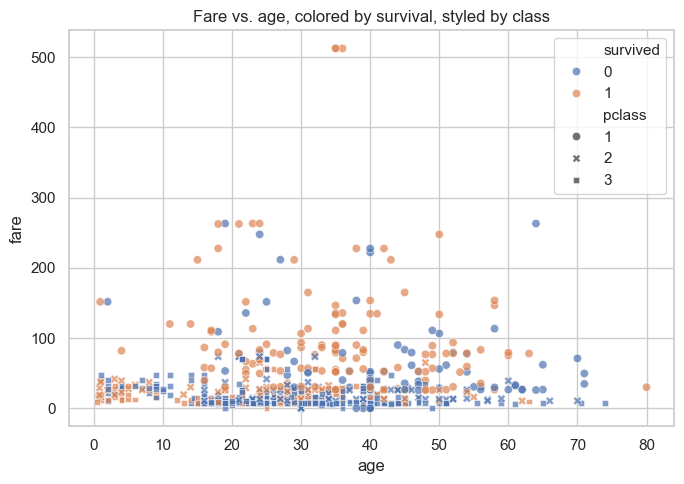

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="age", y="fare", hue="survived", style="pclass", alpha=0.7, ax=ax)
ax.set_title("Fare vs. age, colored by survival, styled by class")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/05_fare_vs_age_survival.png", dpi=120)
plt.show()

**Chart 3 — Fare vs. age, colored by survival.** Survivors (orange) cluster
more densely at higher fares than non-survivors (blue), and this pattern
holds across the age range rather than being driven by a handful of young
passengers. It visually reinforces that fare — a proxy for wealth and
cabin class/location — mattered more to survival than age did on its own.

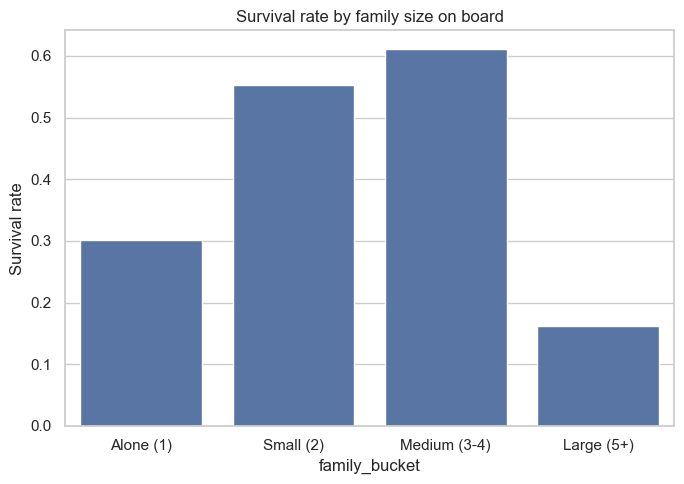

In [15]:
family_size = df["sibsp"] + df["parch"] + 1
family_bucket = pd.cut(
    family_size, bins=[0, 1, 2, 4, 20], labels=["Alone (1)", "Small (2)", "Medium (3-4)", "Large (5+)"]
)
family_df = df.assign(family_bucket=family_bucket)
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=family_df, x="family_bucket", y="survived", ax=ax, errorbar=None, order=[
    "Alone (1)", "Small (2)", "Medium (3-4)", "Large (5+)"
])
ax.set_title("Survival rate by family size on board")
ax.set_ylabel("Survival rate")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/06_survival_by_family_size.png", dpi=120)
plt.show()

**Chart 4 — Survival rate by family size.** Traveling completely alone was
the worst outcome, small families (2–4 people, i.e. couples or a parent
with 1–3 children) did noticeably better, and very large families (5+) did
worst of all — likely a mix of being harder to keep together while
boarding lifeboats and overlapping heavily with large, poorer 3rd-class
families. The "sweet spot" is a small family, not solo travel or a large
group.

## 6. EDA sanity check: z-score standardization of `age` and `fare`

This is an exploratory check only — it does **not** feed into the
modeling pipeline in `02_modeling.ipynb`, which fits its own
`StandardScaler` on the training split only.

In [16]:
before = df[["age", "fare"]].agg(["mean", "std"])
standardized = zscore_standardize(df, ["age", "fare"])
after = standardized[["age", "fare"]].agg(["mean", "std"])
print("Before standardization:\n", before)
print("\nAfter standardization:\n", after)

Before standardization:
             age       fare
mean  29.065433  32.096681
std   13.270162  49.697504

After standardization:
                age          fare
mean  2.517671e-16  1.358743e-16
std   1.000000e+00  1.000000e+00


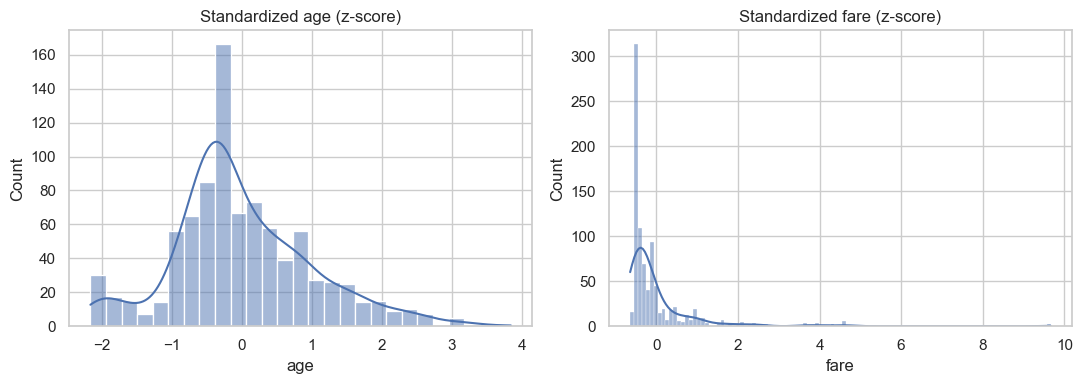

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(standardized["age"], kde=True, ax=axes[0]).set_title("Standardized age (z-score)")
sns.histplot(standardized["fare"], kde=True, ax=axes[1]).set_title("Standardized fare (z-score)")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/07_zscore_check.png", dpi=120)
plt.show()

Both standardized columns now have mean ≈ 0 and standard deviation ≈ 1,
confirming the z-score transform behaved as expected. Shape is unchanged
(standardization doesn't fix skew) — `fare`'s standardized histogram is
still visibly right-skewed, just rescaled.

## Summary

`age` and `fare` were cleaned/imputed above; `deck` and `alive` were
dropped; everything else was kept. This cleaned frame (`df`) is what the
rest of this notebook's charts use. `titanic.csv`, written in step 1, is
the **raw** (pre-cleaning) frame — `02_modeling.ipynb` reads it and
re-applies the exact same `clean_titanic` function from `src/cleaning.py`,
so cleaning logic lives in one place, not duplicated by hand across
notebooks, while the raw dataset is still only ever loaded from the
network/cache once.